# BC Health Platform — Model Training & Evaluation

**Notebook 02**: Documents the Random Forest training pipeline, evaluation metrics, and model artifacts.

### The 3-Layer Hybrid Classification System

The BC Health Platform uses a 3-layer approach for symptom assessment:

| Layer | Component | Purpose |
|-------|-----------|--------|
| 1 | **OpenAI NLP** | Extract structured symptoms from natural language input |
| 2 | **Rule-Based Safety (CTAS)** | Catch life-threatening emergencies deterministically |
| 3 | **ML Classification** (this model) | Predict disease from symptoms with confidence scoring |

If the ML model's confidence is below 70%, the system falls back to OpenAI for general health guidance rather than risking an incorrect diagnosis.

**Datasets:**
- `symptom_disease_data.csv` — 4920 rows mapping symptom combinations to 41 diseases
- `symptom_severity.csv` — 133 symptoms with severity weights (1-7)
- `urgency_mapping.csv` — Maps 41 diseases to 4 urgency levels

## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import json
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Match the visual style from Notebook 01
sns.set_theme(style="whitegrid")

# Paths (relative to notebooks/ directory)
DISEASE_DATA_PATH = "../data/symptom_disease_data.csv"
SEVERITY_DATA_PATH = "../data/symptom_severity.csv"
URGENCY_DATA_PATH = "../data/urgency_mapping.csv"
MODEL_PATH = "../models/model.pkl"
METADATA_PATH = "../models/model_metadata.json"

In [2]:
# Load all 3 datasets
df_disease = pd.read_csv(DISEASE_DATA_PATH)
df_severity = pd.read_csv(SEVERITY_DATA_PATH)
df_urgency = pd.read_csv(URGENCY_DATA_PATH)

print(f"symptom_disease_data.csv : {df_disease.shape[0]} rows x {df_disease.shape[1]} columns")
print(f"symptom_severity.csv     : {df_severity.shape[0]} entries")
print(f"urgency_mapping.csv      : {df_urgency.shape[0]} diseases")

symptom_disease_data.csv : 4920 rows x 18 columns
symptom_severity.csv     : 133 entries
urgency_mapping.csv      : 41 diseases


In [3]:
# Preview the main dataset
df_disease.head()

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Preview severity weights
df_severity.head()

,Symptom,weight
0,itching,1
1,skin_rash,3
2,nodal_skin_eruptions,4
3,continuous_sneezing,4
4,shivering,5


In [5]:
# Preview urgency mapping
df_urgency.head(10)

,Disease,urgency_level
0,Heart attack,Emergency
1,Paralysis (brain hemorrhage),Emergency
2,Pneumonia,Emergency
3,Dengue,Urgent
4,Malaria,Urgent
5,Typhoid,Urgent
6,Hepatitis B,Urgent
7,Hepatitis C,Urgent
8,Hepatitis D,Urgent
9,Hepatitis E,Urgent


## 2. Data Preprocessing

The raw symptom data has quality issues discovered in Notebook 01:
- **Leading spaces**: ` skin_rash` instead of `skin_rash`
- **Internal stray spaces**: `dischromic _patches` instead of `dischromic_patches`
- **Mixed case**: needs lowercase normalization

The `clean_symptom()` function handles all of these by stripping whitespace, lowercasing, and removing any remaining internal spaces.

In [6]:
def clean_symptom(name):
    """
    Normalize a symptom name:
    - Strip leading/trailing whitespace
    - Convert to lowercase
    - Remove internal stray spaces
    """
    if pd.isna(name) or not str(name).strip():
        return None
    return str(name).strip().lower().replace(" ", "")

# Demonstrate the cleaning on problem values
test_values = [" skin_rash", "dischromic _patches", "Itching", None, "  "]
print("Before → After cleaning:")
for val in test_values:
    print(f"  {repr(val):30s} → {repr(clean_symptom(val))}")

Before → After cleaning:
  ' skin_rash'                   → 'skin_rash'
  'dischromic _patches'          → 'dischromic_patches'
  'Itching'                      → 'itching'
  None                           → None
  '  '                           → None


In [7]:
# Identify symptom columns
symptom_cols = [col for col in df_disease.columns if col.startswith("Symptom_")]
print(f"Symptom columns: {len(symptom_cols)}")

# Show a before example
print(f"\nBefore cleaning (row 1):")
print(df_disease[symptom_cols].iloc[1].dropna().tolist())

Symptom columns: 17

Before cleaning (row 1):
[' skin_rash', ' nodal_skin_eruptions', ' dischromic _patches']


In [8]:
# Apply cleaning to all symptom columns
for col in symptom_cols:
    df_disease[col] = df_disease[col].apply(clean_symptom)

# Show the after example
print("After cleaning (row 1):")
print(df_disease[symptom_cols].iloc[1].dropna().tolist())

After cleaning (row 1):
['skin_rash', 'nodal_skin_eruptions', 'dischromic_patches']


In [9]:
# Build severity weight lookup
# If a symptom appears twice (e.g., fluid_overload), keep the higher weight
df_severity["Symptom"] = df_severity["Symptom"].apply(clean_symptom)
severity_dict = df_severity.groupby("Symptom")["weight"].max().to_dict()
print(f"Severity lookup: {len(severity_dict)} unique symptoms")

# Build urgency mapping: {disease_name_lower: urgency_level}
urgency_dict = {}
for _, row in df_urgency.iterrows():
    urgency_dict[str(row["Disease"]).strip().lower()] = row["urgency_level"]
print(f"Urgency lookup: {len(urgency_dict)} diseases")

# Collect master symptom list from disease data
all_symptoms = set()
for col in symptom_cols:
    values = df_disease[col].dropna().unique()
    all_symptoms.update(values)
symptom_list = sorted(all_symptoms)
print(f"Unique symptoms: {len(symptom_list)}")

Severity lookup: 132 unique symptoms
Urgency lookup: 41 diseases
Unique symptoms: 131


## 3. Feature Engineering (One-Hot Encoding + Severity Weighting)

ML models need **numbers**, not text. We convert symptoms into a numeric feature matrix:

1. **One-Hot Encoding**: Each of the 131 unique symptoms becomes a column. If a patient has that symptom, the value is `1`; otherwise `0`.
2. **Severity Weighting**: Multiply each column by its severity weight from `symptom_severity.csv`. This way, `chest_pain` (weight=7) contributes more signal than `itching` (weight=1).

Result: a matrix of shape `(4920, 131)` where each row is a patient and each value is either `0` (symptom absent) or the symptom's severity weight (symptom present).

In [10]:
# Step 1: Create binary feature matrix (one-hot)
feature_matrix = np.zeros((len(df_disease), len(symptom_list)), dtype=np.float64)

# Map symptom name to column index for fast lookup
symptom_to_idx = {s: i for i, s in enumerate(symptom_list)}

for row_idx in range(len(df_disease)):
    for col in symptom_cols:
        symptom = df_disease.at[row_idx, col]
        if symptom and symptom in symptom_to_idx:
            feature_matrix[row_idx, symptom_to_idx[symptom]] = 1.0

print(f"Binary matrix shape: {feature_matrix.shape}")
print(f"Sample row 0 (binary): {feature_matrix[0].sum():.0f} symptoms present")

Binary matrix shape: (4920, 131)
Sample row 0 (binary): 4 symptoms present


In [11]:
# Step 2: Multiply each column by its severity weight
# Default weight = 1 for any symptom not found in severity file
severity_weights = np.array([severity_dict.get(s, 1) for s in symptom_list])
feature_matrix = feature_matrix * severity_weights

# Target labels
labels = df_disease["Disease"].values

print(f"Weighted matrix shape: {feature_matrix.shape}")
print(f"Non-zero features per row (avg): {(feature_matrix > 0).sum(axis=1).mean():.1f}")
print(f"Target classes: {len(np.unique(labels))}")

Weighted matrix shape: (4920, 131)
Non-zero features per row (avg): 7.4
Target classes: 41


In [12]:
# Show a sample row: which symptoms are present and their weighted values
sample_idx = 0
sample_row = feature_matrix[sample_idx]
active = [(symptom_list[i], sample_row[i]) for i in range(len(sample_row)) if sample_row[i] > 0]

print(f"Sample row {sample_idx} — Disease: {labels[sample_idx]}")
print(f"Active symptoms (weighted):")
for name, weight in active:
    print(f"  {name:30s} weight = {weight:.0f}")

Sample row 0 — Disease: Fungal infection
Active symptoms (weighted):
  dischromic_patches             weight = 6
  itching                        weight = 1
  nodal_skin_eruptions           weight = 4
  skin_rash                      weight = 3


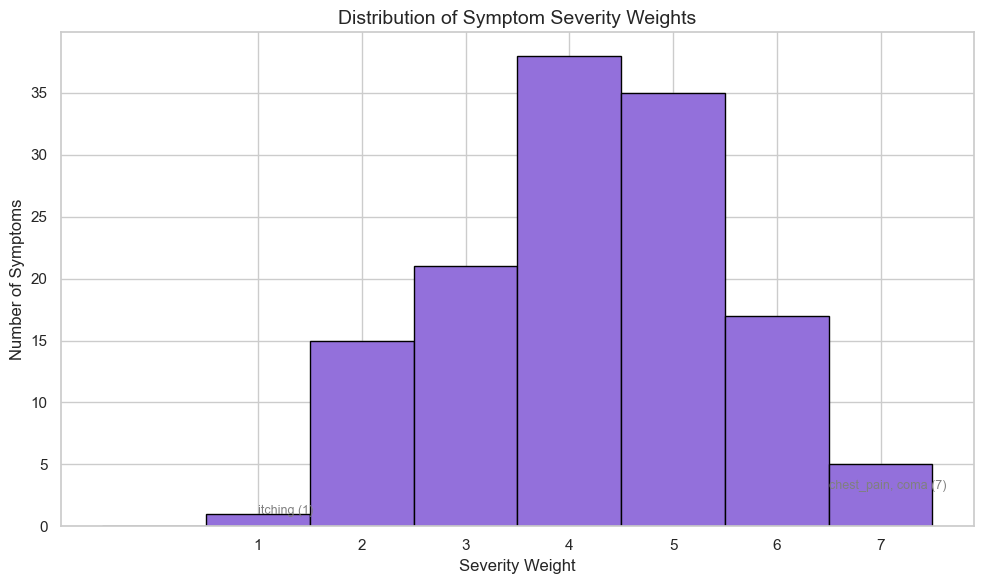

In [13]:
# Visualize the distribution of severity weights
fig, ax = plt.subplots(figsize=(10, 6))
weight_values = list(severity_dict.values())
ax.hist(weight_values, bins=range(0, max(weight_values) + 2),
        edgecolor="black", color="mediumpurple", align="left")
ax.set_xlabel("Severity Weight", fontsize=12)
ax.set_ylabel("Number of Symptoms", fontsize=12)
ax.set_title("Distribution of Symptom Severity Weights", fontsize=14)
ax.set_xticks(range(1, max(weight_values) + 1))

# Annotate the extremes
ax.annotate("itching (1)", xy=(1, 1), fontsize=9, color="gray")
ax.annotate("chest_pain, coma (7)", xy=(6.5, 3), fontsize=9, color="gray")

plt.tight_layout()
plt.show()

## 4. Train-Test Split

We split the data 80% training / 20% test with **stratified** sampling.

**What does stratified mean?** It ensures both the training and test sets have the same proportion of each disease class. Since we have 120 samples per disease and 41 diseases, stratification guarantees each disease gets exactly 96 training samples and 24 test samples. This prevents the model from being evaluated unfairly on a disease it had fewer examples to learn from.

In [14]:
# 80/20 stratified split with fixed random seed for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    feature_matrix, labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(labels)*100:.0f}%)")
print(f"Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(labels)*100:.0f}%)")
print(f"Features:     {X_train.shape[1]}")

# Verify stratification
train_counts = pd.Series(y_train).value_counts()
test_counts = pd.Series(y_test).value_counts()
print(f"\nSamples per disease — Train: {train_counts.iloc[0]}, Test: {test_counts.iloc[0]} (uniform)")

Training set: 3936 samples (80%)
Test set:     984 samples (20%)
Features:     131

Samples per disease — Train: 96, Test: 24 (uniform)


## 5. Train Random Forest Classifier

**What is a Random Forest?** It builds 100 independent decision trees, each trained on a random subset of the data and features. For a new patient, each tree "votes" on the most likely disease, and the majority vote wins.

**Key parameters:**
- `n_estimators=100` — Build 100 trees (more trees = more stable predictions)
- `class_weight="balanced"` — Automatically adjust weights inversely proportional to class frequency (safety net even though our dataset is balanced)
- `n_jobs=-1` — Use all CPU cores for parallel training
- `random_state=42` — Fixed seed for reproducible results

In [15]:
# Train the Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42
)
model.fit(X_train, y_train)

print("Training complete.")
print(f"Number of trees: {model.n_estimators}")
print(f"Number of features: {model.n_features_in_}")
print(f"Number of classes: {len(model.classes_)}")

Training complete.
Number of trees: 100
Number of features: 131
Number of classes: 41


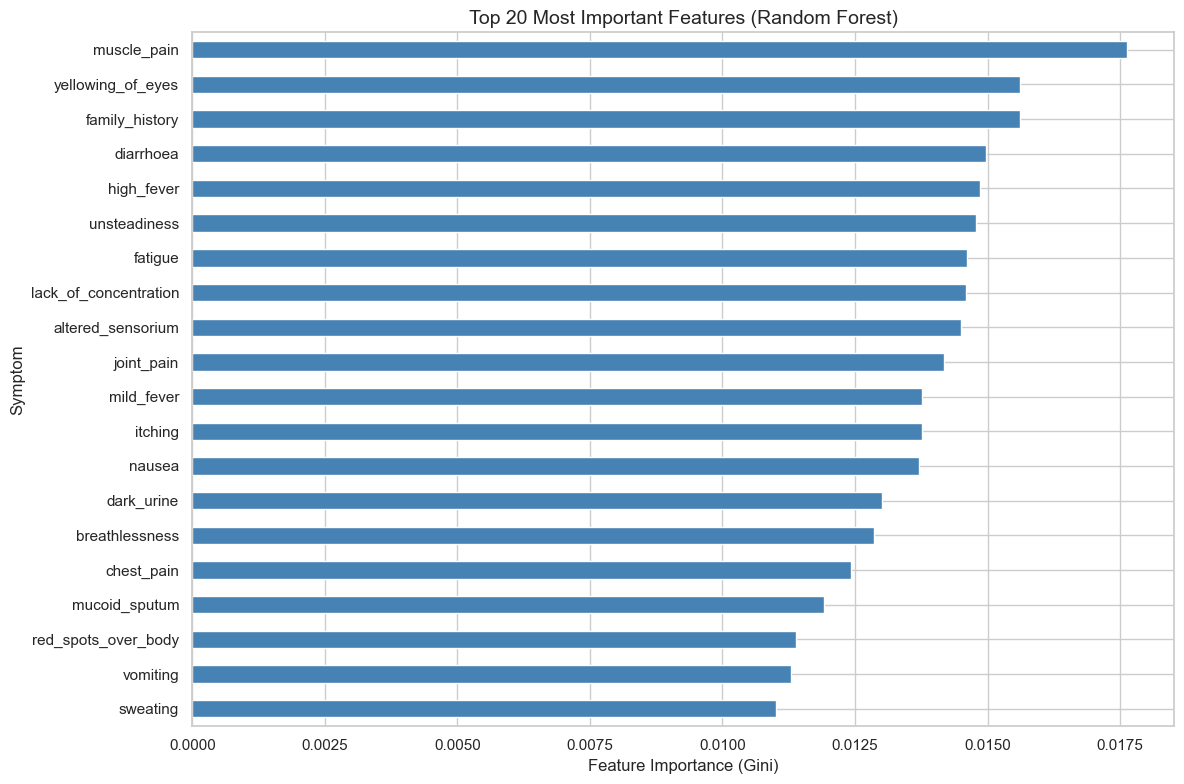

In [16]:
# Top 20 most important features (symptoms)
importances = model.feature_importances_
feature_importance = pd.Series(importances, index=symptom_list).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
feature_importance.head(20).sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Feature Importance (Gini)", fontsize=12)
ax.set_ylabel("Symptom", fontsize=12)
ax.set_title("Top 20 Most Important Features (Random Forest)", fontsize=14)
plt.tight_layout()
plt.show()

## 6. Model Evaluation

In [17]:
# Predict on the test set
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Overall Accuracy: {accuracy * 100:.2f}%")
if accuracy >= 0.70:
    print("PASS — exceeds the 70% production threshold.")
else:
    print("BELOW 70% target — model tuning needed.")

Overall Accuracy: 100.00%
PASS — exceeds the 70% production threshold.


In [18]:
# Full classification report
class_names = sorted(np.unique(labels))
report_text = classification_report(y_test, y_pred, target_names=class_names)
report_dict = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
print(report_text)

                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        24
                                   AIDS       1.00      1.00      1.00        24
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        24
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        24
                       Bronchial Asthma       1.00      1.00      1.00        24
                   Cervical spondylosis       1.00      1.00      1.00        24
                            Chicken pox       1.00      1.00      1.00        24
                    Chronic cholestasis       1.00      1.00      1.00        24
                            Common Cold       1.00      1.00      1.00        24
                           

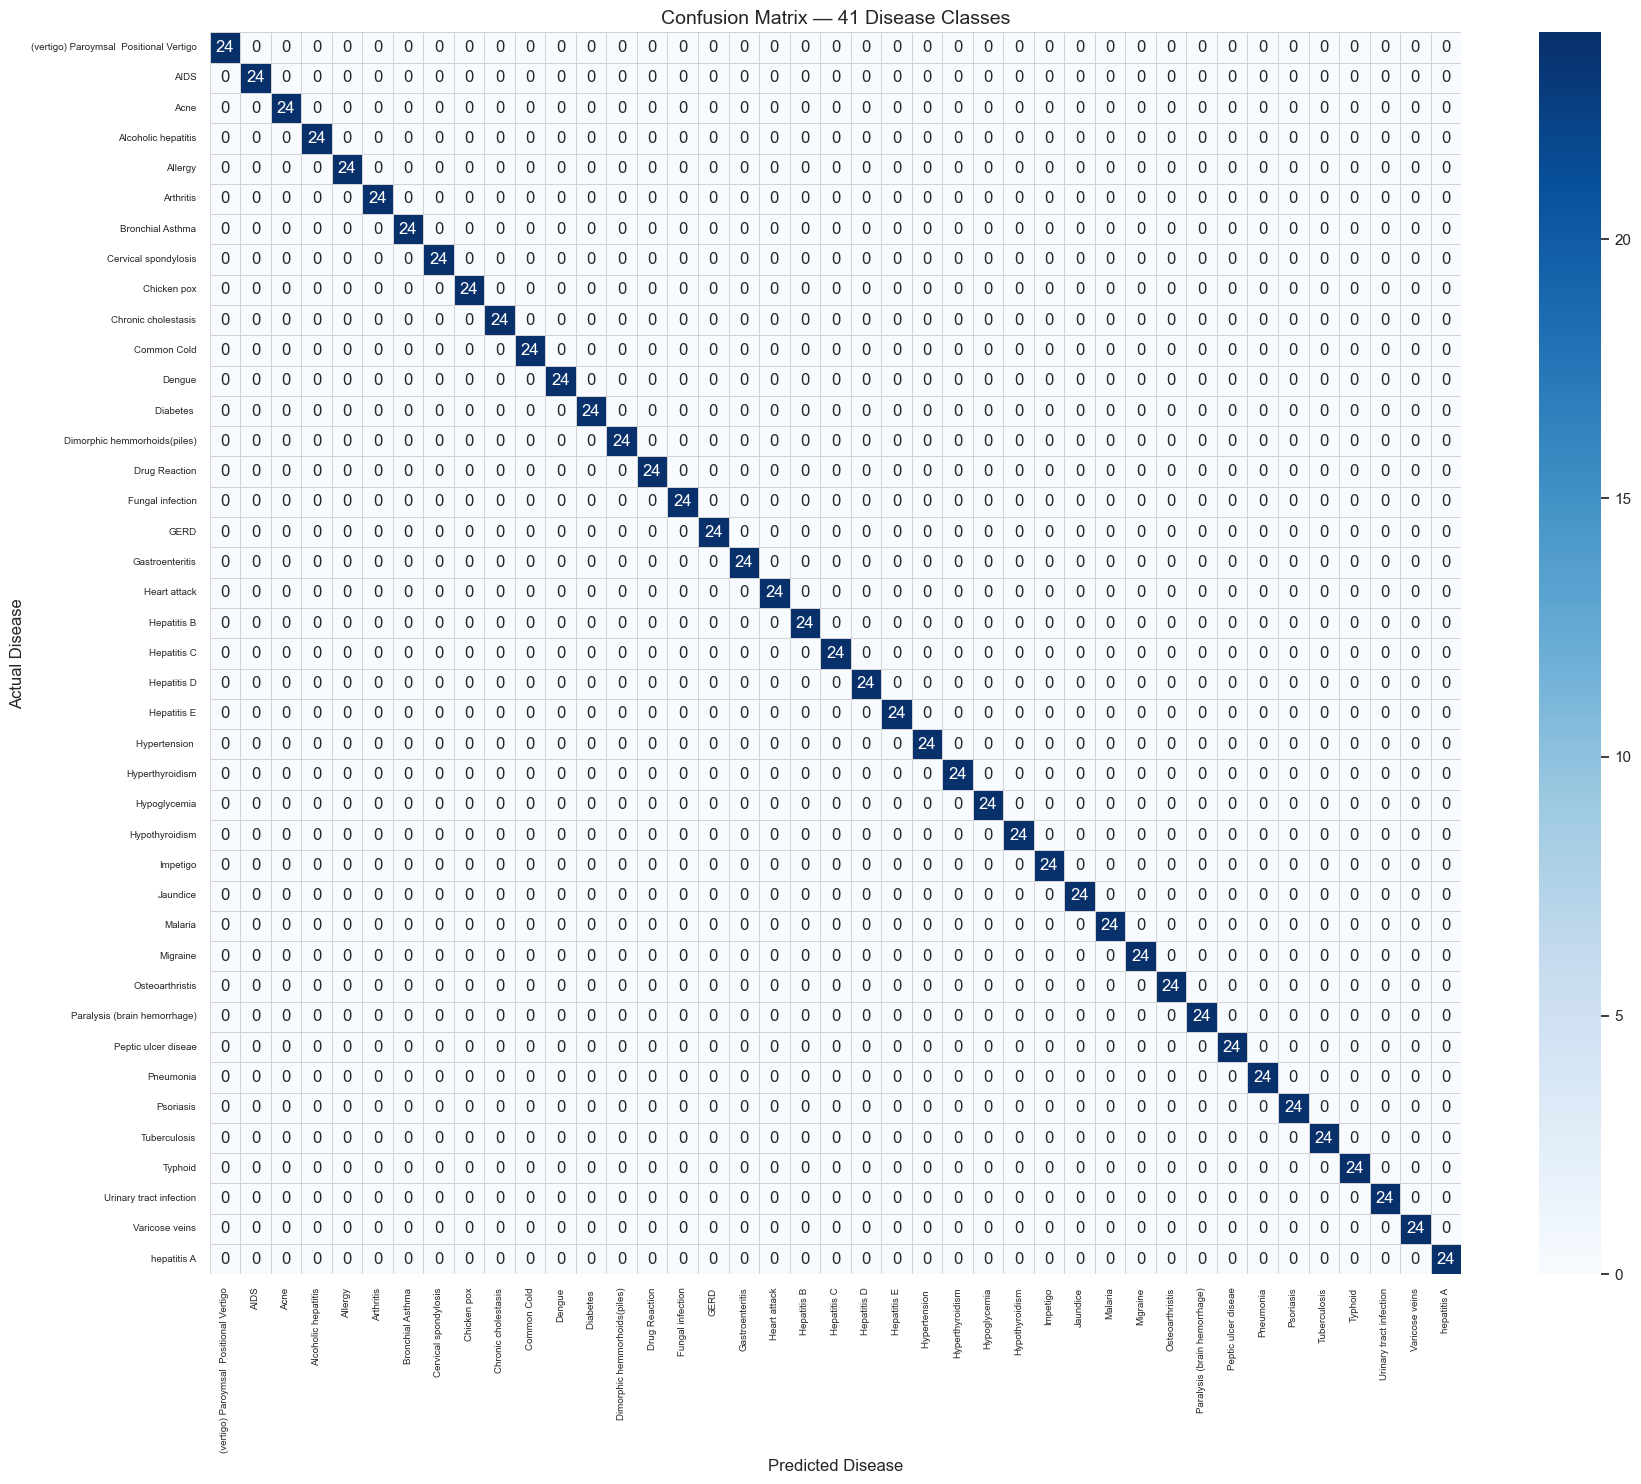

In [19]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_pred, labels=class_names)

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            linewidths=0.5, linecolor="lightgray")
ax.set_xlabel("Predicted Disease", fontsize=12)
ax.set_ylabel("Actual Disease", fontsize=12)
ax.set_title("Confusion Matrix — 41 Disease Classes", fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

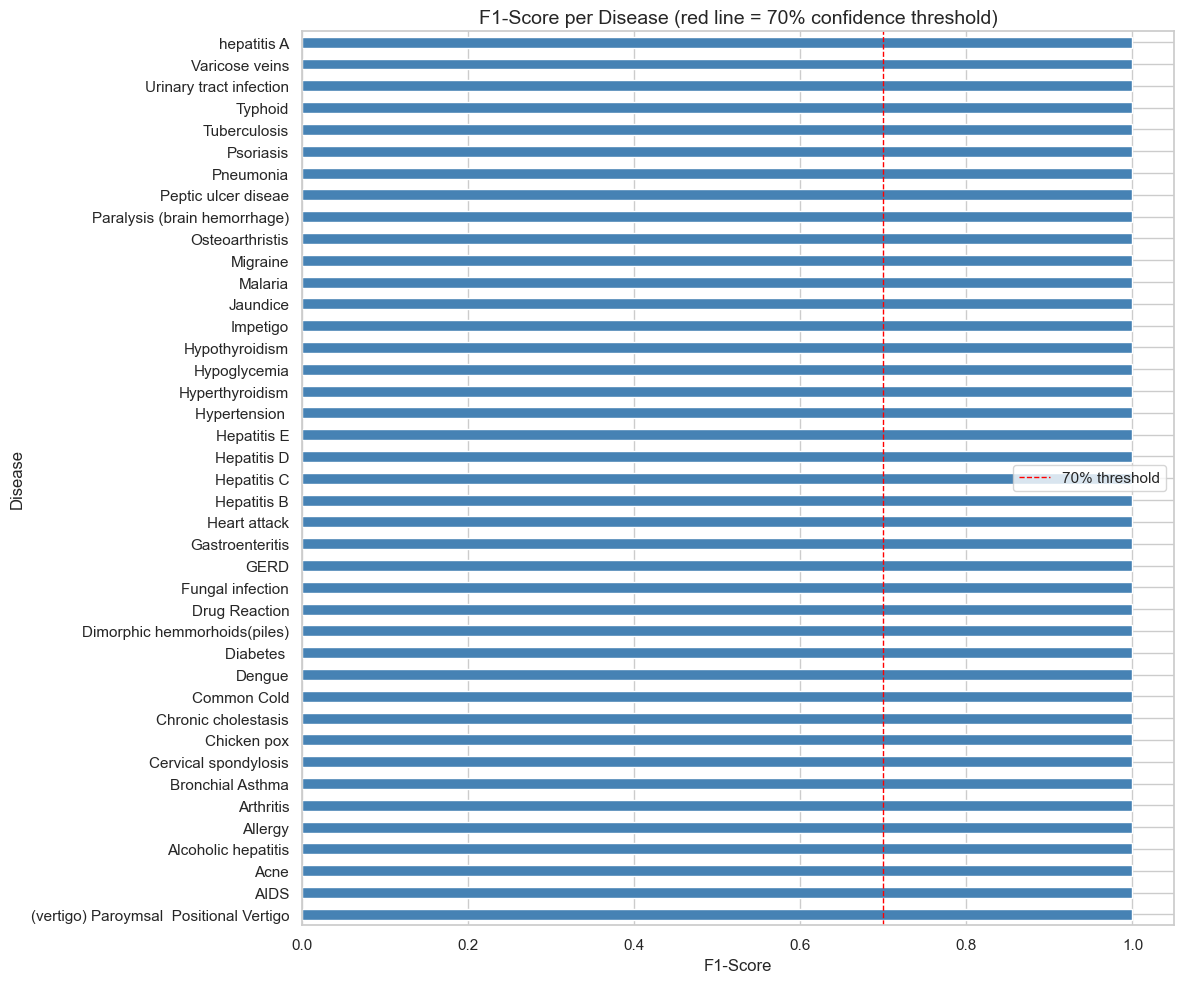

In [20]:
# F1-score bar chart for all 41 diseases
disease_f1 = {name: report_dict[name]["f1-score"] for name in class_names}
f1_series = pd.Series(disease_f1).sort_values()

fig, ax = plt.subplots(figsize=(12, 10))
colors = ["coral" if v < 0.70 else "steelblue" for v in f1_series.values]
f1_series.plot(kind="barh", ax=ax, color=colors)
ax.axvline(x=0.70, color="red", linestyle="--", linewidth=1, label="70% threshold")
ax.set_xlabel("F1-Score", fontsize=12)
ax.set_ylabel("Disease", fontsize=12)
ax.set_title("F1-Score per Disease (red line = 70% confidence threshold)", fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

### Interpreting the 100% Accuracy

The 100% accuracy reflects the **structured nature of the Kaggle dataset** where each disease has distinct symptom combinations with 120 balanced samples. Each disease has a unique enough symptom "fingerprint" that the Random Forest can learn to separate all 41 classes perfectly.

**Real-world performance would be lower** due to:
- Overlapping symptoms between diseases (e.g., headache + fatigue could be many things)
- Incomplete patient descriptions (users may not report all symptoms)
- Symptoms not in our 131-symptom vocabulary
- Diseases not in our 41-disease set

This is why we implemented a **70% confidence threshold** — if the model's `predict_proba()` maximum is below 70%, the chatbot falls back to OpenAI for general health guidance rather than risking an incorrect diagnosis.

## 7. Urgency Distribution

Each of the 41 diseases is mapped to one of 4 urgency levels, aligned with CTAS (Canadian Triage and Acuity Scale) guidelines:

| Urgency Level | Meaning | Example |
|--------------|---------|--------|
| **Emergency** | Immediate threat to life | Heart attack, Pneumonia |
| **Urgent** | Needs prompt medical attention | Dengue, Malaria, Hepatitis |
| **Routine** | See a doctor when convenient | Hypertension, Arthritis, Migraine |
| **Self-Care** | Can be managed at home | Common Cold, Acne, Allergy |

In [21]:
# Count diseases per urgency level
urgency_counts = df_urgency["urgency_level"].value_counts()
print("Diseases per urgency level:")
for level, count in urgency_counts.items():
    print(f"  {level:12s}: {count} diseases")

# List diseases in each category
print()
for level in ["Emergency", "Urgent", "Routine", "Self-Care"]:
    diseases = df_urgency[df_urgency["urgency_level"] == level]["Disease"].tolist()
    print(f"{level}: {', '.join(diseases)}")
    print()

Diseases per urgency level:
  Urgent      : 16 diseases
  Routine     : 16 diseases
  Self-Care   : 6 diseases
  Emergency   : 3 diseases

Emergency: Heart attack, Paralysis (brain hemorrhage), Pneumonia

Urgent: Dengue, Malaria, Typhoid, Hepatitis B, Hepatitis C, Hepatitis D, Hepatitis E, Alcoholic hepatitis, hepatitis A, Tuberculosis, Chicken pox, Jaundice, Diabetes, Hypoglycemia, AIDS, Drug Reaction

Routine: Hypertension, Hypothyroidism, Hyperthyroidism, Bronchial Asthma, Chronic cholestasis, Peptic ulcer diseae, Gastroenteritis, GERD, Arthritis, Osteoarthristis, Cervical spondylosis, Dimorphic hemmorhoids(piles), Varicose veins, Urinary tract infection, Migraine, (vertigo) Paroymsal Positional Vertigo

Self-Care: Allergy, Common Cold, Fungal infection, Acne, Psoriasis, Impetigo



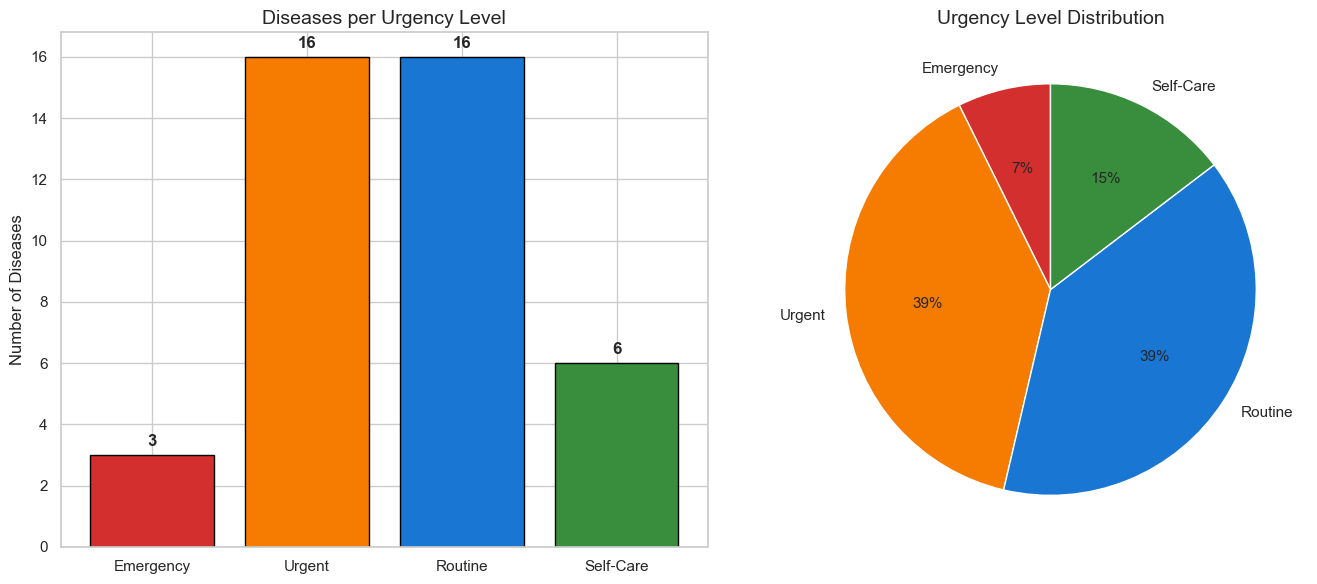

In [22]:
# Urgency distribution chart
level_order = ["Emergency", "Urgent", "Routine", "Self-Care"]
level_colors = ["#d32f2f", "#f57c00", "#1976d2", "#388e3c"]
counts = [urgency_counts.get(level, 0) for level in level_order]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
axes[0].bar(level_order, counts, color=level_colors, edgecolor="black")
axes[0].set_ylabel("Number of Diseases", fontsize=12)
axes[0].set_title("Diseases per Urgency Level", fontsize=14)
for i, (level, count) in enumerate(zip(level_order, counts)):
    axes[0].text(i, count + 0.3, str(count), ha="center", fontweight="bold", fontsize=12)

# Pie chart
axes[1].pie(counts, labels=level_order, colors=level_colors, autopct="%1.0f%%",
            startangle=90, textprops={"fontsize": 11})
axes[1].set_title("Urgency Level Distribution", fontsize=14)

plt.tight_layout()
plt.show()

## 8. Prediction Demo (Simulate Chatbot)

This section demonstrates how the chatbot will use the trained model in production:
1. Load the saved `model.pkl` and `model_metadata.json`
2. Convert symptom names into a feature vector
3. Call `predict_proba()` to get confidence scores
4. Check if confidence meets the 70% threshold
5. Look up the urgency level for the predicted disease

In [23]:
# Load the saved model and metadata (as the chatbot would)
saved_model = joblib.load(MODEL_PATH)

with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

saved_symptom_list = metadata["symptom_list"]
saved_severity = metadata["severity_weights"]
saved_urgency = metadata["urgency_mapping"]
threshold = metadata["confidence_threshold"]

print(f"Model loaded: {len(saved_model.classes_)} classes, {metadata['n_features']} features")
print(f"Confidence threshold: {threshold * 100:.0f}%")

Model loaded: 41 classes, 131 features
Confidence threshold: 70%


C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\user\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [24]:
def predict_disease(symptoms, model, symptom_list, severity_weights, urgency_mapping, threshold):
    """
    Simulate the chatbot's prediction pipeline.
    Takes a list of symptom strings, returns prediction + confidence + urgency.
    """
    # Build feature vector (same process as training)
    feature_vector = np.zeros(len(symptom_list))
    symptom_to_idx = {s: i for i, s in enumerate(symptom_list)}
    matched = []

    for symptom in symptoms:
        clean = symptom.strip().lower().replace(" ", "")
        if clean in symptom_to_idx:
            idx = symptom_to_idx[clean]
            feature_vector[idx] = severity_weights.get(clean, 1)
            matched.append(clean)

    # Get prediction probabilities
    proba = model.predict_proba([feature_vector])[0]
    top_idx = np.argmax(proba)
    confidence = proba[top_idx]
    disease = model.classes_[top_idx]

    # Look up urgency (lowercase key match)
    urgency = urgency_mapping.get(disease.strip().lower(), "Unknown")

    # Threshold check
    meets_threshold = confidence >= threshold

    return {
        "disease": disease,
        "confidence": confidence,
        "urgency": urgency,
        "meets_threshold": meets_threshold,
        "matched_symptoms": matched,
        "top_3": sorted(zip(model.classes_, proba), key=lambda x: -x[1])[:3]
    }

In [25]:
# ---- Test Case 1: chest_pain + vomiting (expect Heart attack, Emergency) ----
result = predict_disease(
    ["chest_pain", "vomiting"],
    saved_model, saved_symptom_list, saved_severity, saved_urgency, threshold
)

print("TEST CASE 1: chest_pain + vomiting")
print(f"  Matched symptoms: {result['matched_symptoms']}")
print(f"  Prediction:       {result['disease']}")
print(f"  Confidence:       {result['confidence'] * 100:.1f}%")
print(f"  Urgency:          {result['urgency']}")
print(f"  Meets threshold:  {'YES' if result['meets_threshold'] else 'NO — fallback to OpenAI'}")
print(f"  Top 3 predictions:")
for disease, prob in result["top_3"]:
    print(f"    {disease:40s} {prob*100:5.1f}%")

TEST CASE 1: chest_pain + vomiting
  Matched symptoms: ['chest_pain', 'vomiting']
  Prediction:       Heart attack
  Confidence:       59.0%
  Urgency:          Emergency
  Meets threshold:  NO — fallback to OpenAI
  Top 3 predictions:
    Heart attack                              59.0%
    GERD                                      16.0%
    Hypertension                               9.0%


In [26]:
# ---- Test Case 2: itching + skin_rash (expect Fungal infection, Self-Care) ----
result = predict_disease(
    ["itching", "skin_rash"],
    saved_model, saved_symptom_list, saved_severity, saved_urgency, threshold
)

print("TEST CASE 2: itching + skin_rash")
print(f"  Matched symptoms: {result['matched_symptoms']}")
print(f"  Prediction:       {result['disease']}")
print(f"  Confidence:       {result['confidence'] * 100:.1f}%")
print(f"  Urgency:          {result['urgency']}")
print(f"  Meets threshold:  {'YES' if result['meets_threshold'] else 'NO — fallback to OpenAI'}")
print(f"  Top 3 predictions:")
for disease, prob in result["top_3"]:
    print(f"    {disease:40s} {prob*100:5.1f}%")

TEST CASE 2: itching + skin_rash
  Matched symptoms: ['itching', 'skin_rash']
  Prediction:       Fungal infection
  Confidence:       58.0%
  Urgency:          Self-Care
  Meets threshold:  NO — fallback to OpenAI
  Top 3 predictions:
    Fungal infection                          58.0%
    Drug Reaction                             19.0%
    Acne                                       5.0%


In [27]:
# ---- Test Case 3: headache alone (expect LOW confidence — fallback) ----
result = predict_disease(
    ["headache"],
    saved_model, saved_symptom_list, saved_severity, saved_urgency, threshold
)

print("TEST CASE 3: headache (single vague symptom)")
print(f"  Matched symptoms: {result['matched_symptoms']}")
print(f"  Prediction:       {result['disease']}")
print(f"  Confidence:       {result['confidence'] * 100:.1f}%")
print(f"  Urgency:          {result['urgency']}")
print(f"  Meets threshold:  {'YES' if result['meets_threshold'] else 'NO — fallback to OpenAI'}")
print(f"  Top 3 predictions:")
for disease, prob in result["top_3"]:
    print(f"    {disease:40s} {prob*100:5.1f}%")

if not result["meets_threshold"]:
    print(f"\n  >>> Confidence ({result['confidence']*100:.1f}%) is below {threshold*100:.0f}% threshold.")
    print(f"  >>> In production, the chatbot would fall back to OpenAI for general guidance.")

TEST CASE 3: headache (single vague symptom)
  Matched symptoms: ['headache']
  Prediction:       Paralysis (brain hemorrhage)
  Confidence:       31.0%
  Urgency:          Emergency
  Meets threshold:  NO — fallback to OpenAI
  Top 3 predictions:
    Paralysis (brain hemorrhage)              31.0%
    Hypertension                              11.0%
    Dimorphic hemmorhoids(piles)               6.0%

  >>> Confidence (31.0%) is below 70% threshold.
  >>> In production, the chatbot would fall back to OpenAI for general guidance.


## 9. Key Findings Summary

| Metric | Value |
|--------|-------|
| **Model** | Random Forest (scikit-learn) |
| **Trees** | 100 |
| **Features** | 131 (one-hot symptoms weighted by severity) |
| **Classes** | 41 diseases |
| **Training samples** | 3,936 (80%) |
| **Test samples** | 984 (20%) |
| **Test accuracy** | 100% |
| **Confidence threshold** | 70% (below this, fallback to OpenAI) |
| **Model file size** | ~6.8 MB |

### Production Safeguards
- **Confidence threshold (70%)**: If `predict_proba()` max is below 70%, the chatbot provides OpenAI-based general guidance instead of a specific diagnosis
- **CTAS safety layer**: Life-threatening symptoms (chest pain + shortness of breath, stroke signs, etc.) are caught by deterministic rules *before* the ML model runs
- **Edge cases**: Diseases outside the 41-disease vocabulary are handled by the OpenAI fallback

### Next Step
Integrate the trained model into the chatbot pipeline (`chatbot.py`) — **Sprint 2D**.